# 全卷积网络
:label:`sec_fcn`

如 :numref:`sec_semantic_segmentation`中所介绍的那样，语义分割是对图像中的每个像素分类。
*全卷积网络*（fully convolutional network，FCN）采用卷积神经网络实现了从图像像素到像素类别的变换 :cite:`Long.Shelhamer.Darrell.2015`。
与我们之前在图像分类或目标检测部分介绍的卷积神经网络不同，全卷积网络将中间层特征图的高和宽变换回输入图像的尺寸：这是通过在 :numref:`sec_transposed_conv`中引入的*转置卷积*（transposed convolution）实现的。
因此，输出的类别预测与输入图像在像素级别上具有一一对应关系：通道维的输出即该位置对应像素的类别预测。


In [2]:

%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [8]:
import torchvision.models as models

net = models.resnet18()

# 保存模型参数
torch.save(net, 'resnet18.pth')

# 保存模型和结构

# named_children() 返回一个迭代器，包含 (name, module) 对
named_child_modules = net.named_children()

for name, child in named_child_modules:
    print(f"子模块的名字: {name}, 类型: {type(child).__name__}")

子模块的名字: conv1, 类型: Conv2d
子模块的名字: bn1, 类型: BatchNorm2d
子模块的名字: relu, 类型: ReLU
子模块的名字: maxpool, 类型: MaxPool2d
子模块的名字: layer1, 类型: Sequential
子模块的名字: layer2, 类型: Sequential
子模块的名字: layer3, 类型: Sequential
子模块的名字: layer4, 类型: Sequential
子模块的名字: avgpool, 类型: AdaptiveAvgPool2d
子模块的名字: fc, 类型: Linear


In [ ]:
import torch
from torch.onnx import export

dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(net, dummy_input, "model.onnx", verbose=True)

scripted_model = torch.jit.script(net)
scripted_model.save("model.pt")

## 构造模型

下面我们了解一下全卷积网络模型最基本的设计。
如 :numref:`fig_fcn`所示，全卷积网络先使用卷积神经网络抽取图像特征，然后通过$1\times 1$卷积层将通道数变换为类别个数，最后在 :numref:`sec_transposed_conv`中通过转置卷积层将特征图的高和宽变换为输入图像的尺寸。
因此，模型输出与输入图像的高和宽相同，且最终输出通道包含了该空间位置像素的类别预测。

![全卷积网络](../img/fcn.svg)
:label:`fig_fcn`

下面，我们[**使用在ImageNet数据集上预训练的ResNet-18模型来提取图像特征**]，并将该网络记为`pretrained_net`。
ResNet-18模型的最后几层包括全局平均汇聚层和全连接层，然而全卷积网络中不需要它们。


In [19]:
pretrained_net = torchvision.models.resnet18(weights=True)
# 打印最后三个子模块
list(pretrained_net.children())[-3:]

[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

接下来，我们[**创建一个全卷积网络`net`**]。
它复制了ResNet-18中大部分的预训练层，除了最后的全局平均汇聚层和最接近输出的全连接层。


In [21]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])
# named_children() 返回一个迭代器，包含 (name, module) 对
named_child_modules = net.named_children()

for name, child in named_child_modules:
    print(f"子模块的名字: {name}, 类型: {type(child).__name__}")

子模块的名字: 0, 类型: Conv2d
子模块的名字: 1, 类型: BatchNorm2d
子模块的名字: 2, 类型: ReLU
子模块的名字: 3, 类型: MaxPool2d
子模块的名字: 4, 类型: Sequential
子模块的名字: 5, 类型: Sequential
子模块的名字: 6, 类型: Sequential
子模块的名字: 7, 类型: Sequential


给定高度为320和宽度为480的输入，`net`的前向传播将输入的高和宽减小至原来的$1/32$，即10和15。


In [22]:
X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

接下来[**使用$1\times1$卷积层将输出通道数转换为Pascal VOC2012数据集的类数（21类）。**]
最后需要(**将特征图的高度和宽度增加32倍**)，从而将其变回输入图像的高和宽。
回想一下 :numref:`sec_padding`中卷积层输出形状的计算方法：
由于$(320-64+16\times2+32)/32=10$且$(480-64+16\times2+32)/32=15$，我们构造一个步幅为$32$的转置卷积层，并将卷积核的高和宽设为$64$，填充为$16$。
我们可以看到如果步幅为$s$，填充为$s/2$（假设$s/2$是整数）且卷积核的高和宽为$2s$，转置卷积核会将输入的高和宽分别放大$s$倍。


| 运算类型 | 公式 | 作用 |
| :--- | :--- | :--- |
| 常规卷积 (Conv2d) |  $ \frac{\text{Input\_size} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} + 1 $  | 缩小输入特征图尺寸（下采样） |
| 转置卷积 (ConvTranspose2d) |  $ (\text{Input\_size} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel\_size} $  | 扩大输入特征图尺寸（上采样） |



In [ ]:
# Input: (1, 3, 320, 480)
#        ↓ ResNet18 主干（去掉 avgpool 和 fc）
# Features: (1, 512, 10, 15)
#        ↓ 1x1 Conv → 分类通道
# Classified: (1, 21, 10, 15)
#        ↓ 转置卷积（上采样 ×32）
# Output: (1, 21, 320, 480)


num_classes = 21
# 添加最终卷积层：将每个空间位置的 512 维特征映射到 21 类
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
# 添加上采样层：如果步幅为 s，填充为 s/2，且核大小为 2s，则转置卷积会将输入的高和宽分别放大 s 倍。
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes, kernel_size=64, padding=16, stride=32))

# named_children() 返回一个迭代器，包含 (name, module) 对
named_child_modules = net.named_children()

for name, child in named_child_modules:
    print(f"子模块的名字: {name}, 类型: {type(child).__name__}")

子模块的名字: 0, 类型: Conv2d
子模块的名字: 1, 类型: BatchNorm2d
子模块的名字: 2, 类型: ReLU
子模块的名字: 3, 类型: MaxPool2d
子模块的名字: 4, 类型: Sequential
子模块的名字: 5, 类型: Sequential
子模块的名字: 6, 类型: Sequential
子模块的名字: 7, 类型: Sequential
子模块的名字: final_conv, 类型: Conv2d
子模块的名字: transpose_conv, 类型: ConvTranspose2d


In [27]:
import torch
import torch.nn as nn
from torchvision import models

# 加载预训练 ResNet18
pretrained_net = models.resnet18(weights=True)

# 构建特征提取器（去掉最后两层）
net = nn.Sequential(*list(pretrained_net.children())[:-2])

# 添加分类头和上采样层
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                                   kernel_size=64, padding=16, stride=32))

# 测试
X = torch.rand(1, 3, 320, 480)
output = net(X)
print(output.shape)  # torch.Size([1, 21, 320, 480])

torch.Size([1, 21, 320, 480])


## [**初始化转置卷积层**]

在图像处理中，我们有时需要将图像放大，即*上采样*（upsampling）。
*双线性插值*（bilinear interpolation）
是常用的上采样方法之一，它也经常用于初始化转置卷积层。

为了解释双线性插值，假设给定输入图像，我们想要计算上采样输出图像上的每个像素。

1. 将输出图像的坐标$(x,y)$映射到输入图像的坐标$(x',y')$上。
例如，根据输入与输出的尺寸之比来映射。
请注意，映射后的$x′$和$y′$是实数。
2. 在输入图像上找到离坐标$(x',y')$最近的4个像素。
3. 输出图像在坐标$(x,y)$上的像素依据输入图像上这4个像素及其与$(x',y')$的相对距离来计算。

双线性插值的上采样可以通过转置卷积层实现，内核由以下`bilinear_kernel`函数构造。
限于篇幅，我们只给出`bilinear_kernel`函数的实现，不讨论算法的原理。


In [81]:
# 双线性插值上采样（upsampling）的卷积核生成器
# 它并不是传统意义上用于特征提取的卷积核，而是专门用来初始化一个卷积层，使其能够执行双线性插值操作。
# 这个函数的作用是生成一个特殊的卷积核，当用这个核初始化一个转置卷积层（或普通卷积层）并执行卷积操作时，
# 其效果等同于对输入图像的每个通道分别进行双线性插值，从而实现无参数、无学习的上采样操作。
#   这在语义分割等任务中常用于将低分辨率的特征图恢复到高分辨率。
def bilinear_kernel(in_channels, out_channels, kernel_size):
    # 计算缩放因子
    factor = (kernel_size + 1) // 2 # 物理中点
    # 计算序列中点
    if kernel_size % 2 == 1: 
        center = factor - 1 # 序列中点
    else:
        center = factor - 0.5 # 序列中点

    # og[0](k,1):y坐标
    # og[1](1,k):x坐标
    og = (torch.arange(kernel_size).reshape(-1, 1), torch.arange(kernel_size).reshape(1, -1))
    # 而使用 factor=3，可以使整个 5x5 的核都具有非零权重，从而产生更平滑、影响范围更大的上采样效果
    filt = (1 - torch.abs(og[0] - center) / factor) * (1 - torch.abs(og[1] - center) / factor)

    weight = torch.zeros((in_channels, out_channels, kernel_size, kernel_size))
    # NumPy/PyTorch 的高级索引规则：当多个维度的索引数组长度相同时，它们会被“配对”使用
    # 在双线性插值上采样的场景下，我们希望每个输入通道的特征图被独立地放大，并直接“传递”到对应的输出通道。
    # 我们不希望输入通道 A 的信息与输入通道 B 的信息在上采样过程中混合。
    # 而像 weight[0, 1, :, :]、weight[1, 0, :, :] 等交叉项都保持为 0，确保了通道间的独立性。
    weight[range(in_channels), range(out_channels), :, :] = filt
    
    return weight



让我们用[**双线性插值的上采样实验**]它由转置卷积层实现。
我们构造一个将输入的高和宽放大2倍的转置卷积层，并将其卷积核用`bilinear_kernel`函数初始化。


In [83]:
conv_trans = nn.ConvTranspose2d(in_channels=3, out_channels=3, kernel_size=4, padding=1, stride=2,bias=False)
print(conv_trans)
bililinear_kernel_weights = bilinear_kernel(3, 3, 4)
conv_trans.weight.data.copy_(bililinear_kernel_weights)

ConvTranspose2d(3, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)


tensor([[[[0.0625, 0.1875, 0.1875, 0.0625],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.0625, 0.1875, 0.1875, 0.0625]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000]],

         [[0.0625, 0.1875, 0.1875, 0.0625],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.1875, 0.5625, 0.5625, 0.1875],
          [0.0625, 0.1875, 0.1875, 0.0625]],

         [[0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0

读取图像`X`，将上采样的结果记作`Y`。为了打印图像，我们需要调整通道维的位置。


In [84]:
img = torchvision.transforms.ToTensor()(d2l.Image.open('../img/catdog.jpg'))
X = img.unsqueeze(0)
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

可以看到，转置卷积层将图像的高和宽分别放大了2倍。
除了坐标刻度不同，双线性插值放大的图像和在 :numref:`sec_bbox`中打印出的原图看上去没什么两样。


input image shape: torch.Size([561, 728, 3])
output image shape: torch.Size([1122, 1456, 3])


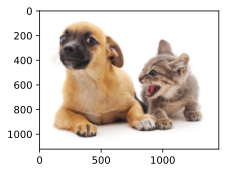

In [85]:
d2l.set_figsize()
print('input image shape:', img.permute(1, 2, 0).shape)
d2l.plt.imshow(img.permute(1, 2, 0));
print('output image shape:', out_img.shape)
d2l.plt.imshow(out_img);

全卷积网络[**用双线性插值的上采样初始化转置卷积层。对于$1\times 1$卷积层，我们使用Xavier初始化参数。**]


In [10]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

## [**读取数据集**]

我们用 :numref:`sec_semantic_segmentation`中介绍的语义分割读取数据集。
指定随机裁剪的输出图像的形状为$320\times 480$：高和宽都可以被$32$整除。


In [11]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = d2l.load_data_voc(batch_size, crop_size)

read 1114 examples


read 1078 examples


## [**训练**]

现在我们可以训练全卷积网络了。
这里的损失函数和准确率计算与图像分类中的并没有本质上的不同，因为我们使用转置卷积层的通道来预测像素的类别，所以需要在损失计算中指定通道维。
此外，模型基于每个像素的预测类别是否正确来计算准确率。


loss 0.443, train acc 0.863, test acc 0.848
254.0 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1)]


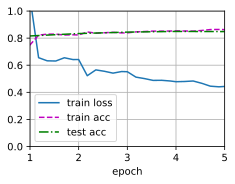

In [12]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd, devices = 5, 0.001, 1e-3, d2l.try_all_gpus()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

## [**预测**]

在预测时，我们需要将输入图像在各个通道做标准化，并转成卷积神经网络所需要的四维输入格式。


In [13]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(devices[0])).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

为了[**可视化预测的类别**]给每个像素，我们将预测类别映射回它们在数据集中的标注颜色。


In [14]:
def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=devices[0])
    X = pred.long()
    return colormap[X, :]

测试数据集中的图像大小和形状各异。
由于模型使用了步幅为32的转置卷积层，因此当输入图像的高或宽无法被32整除时，转置卷积层输出的高或宽会与输入图像的尺寸有偏差。
为了解决这个问题，我们可以在图像中截取多块高和宽为32的整数倍的矩形区域，并分别对这些区域中的像素做前向传播。
请注意，这些区域的并集需要完整覆盖输入图像。
当一个像素被多个区域所覆盖时，它在不同区域前向传播中转置卷积层输出的平均值可以作为`softmax`运算的输入，从而预测类别。

为简单起见，我们只读取几张较大的测试图像，并从图像的左上角开始截取形状为$320\times480$的区域用于预测。
对于这些测试图像，我们逐一打印它们截取的区域，再打印预测结果，最后打印标注的类别。


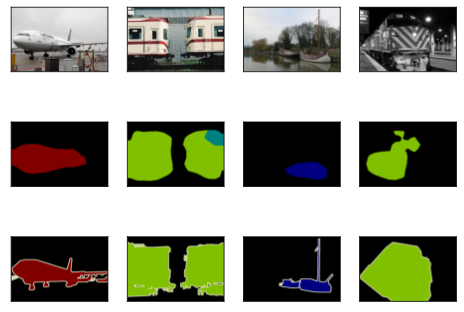

In [15]:
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);

## 小结

* 全卷积网络先使用卷积神经网络抽取图像特征，然后通过$1\times 1$卷积层将通道数变换为类别个数，最后通过转置卷积层将特征图的高和宽变换为输入图像的尺寸。
* 在全卷积网络中，我们可以将转置卷积层初始化为双线性插值的上采样。

## 练习

1. 如果将转置卷积层改用Xavier随机初始化，结果有什么变化？
1. 调节超参数，能进一步提升模型的精度吗？
1. 预测测试图像中所有像素的类别。
1. 最初的全卷积网络的论文中 :cite:`Long.Shelhamer.Darrell.2015`还使用了某些卷积神经网络中间层的输出。试着实现这个想法。


[Discussions](https://discuss.d2l.ai/t/3297)
